<a href="https://colab.research.google.com/github/jemspatel11/netfirst1/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Upload

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv.zip to netflix_titles.csv (6).zip


Import the libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Step 1 — Load & Inspect **Data**

In [ ]:
import pandas as pd

df = pd.read_csv('/content/netflix_titles.csv.zip')

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

df.head()

Shape: (8807, 12)

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Records:
0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


5-Line Summary

The dataset contains 8807 rows and 12 columns.

It contains information about Netflix Movies and TV Shows.

Important attributes include title, director, cast, country, rating, and release year.

Missing values exist mainly in director, cast, and country columns.

The dataset can be used to analyze Netflix content trends.

Step 2 — Clean Data

Missing Values

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Fill Missing Values

In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

Remove Date Missing Rows

In [ ]:
df.dropna(subset=['date_added'], inplace=True)

Remove Duplicates

In [ ]:
df.drop_duplicates(inplace=True)

Convert Date Type

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

Cleaning Decisions

Filled missing directors with "Unknown".

Filled missing cast with "Not Available".

Filled missing country with "Unknown".

Removed rows with missing date_added.

Converted date_added to datetime format.

Removed duplicate records.

Step 3 — Exploratory Data Analysis

Question 1: How many Movies and TV Shows?

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2666


Question 2: Top 10 Countries by Content

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2812
India,972
Unknown,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


Question 3: Distribution of Ratings

In [ ]:
df['rating'].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


Question 4: Content Released Each Year

In [ ]:
df.groupby('release_year')['title'].count().tail(10)

,title
release_year,
2012,236
2013,287
2014,352
2015,558
2016,901
2017,1032
2018,1146
2019,1030
2020,953


Question 5: Top 10 Genres

Step 4 — Visualizations

1. Bar Chart

Movies vs TV Shows

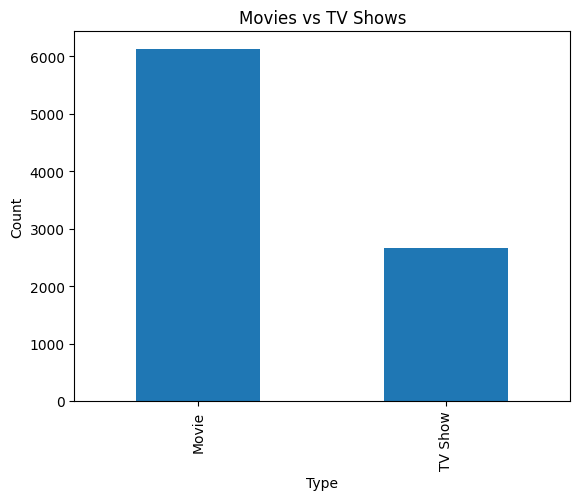

In [ ]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

2. Line Chart

Content Released Over Years

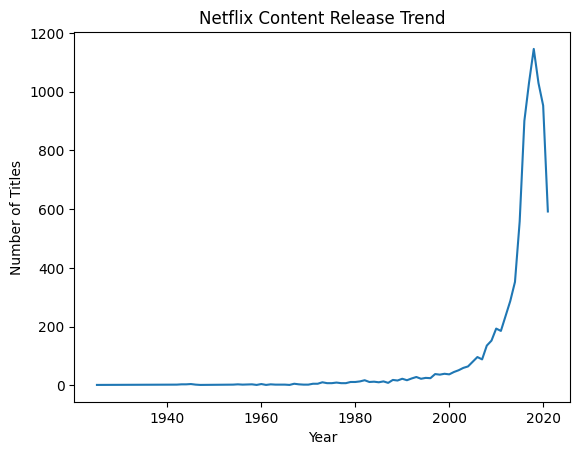

In [ ]:
df.groupby('release_year')['title'].count().plot()
plt.title("Netflix Content Release Trend")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

3. Histogram

Release Year Distribution

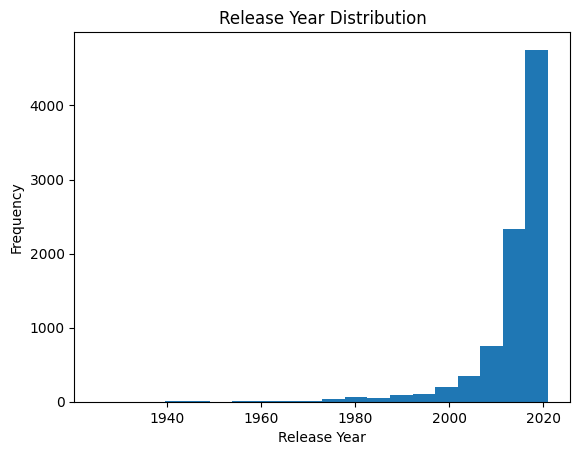

In [ ]:
plt.hist(df['release_year'], bins=20)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

4. Scatter Plot

Release Year vs Show Index

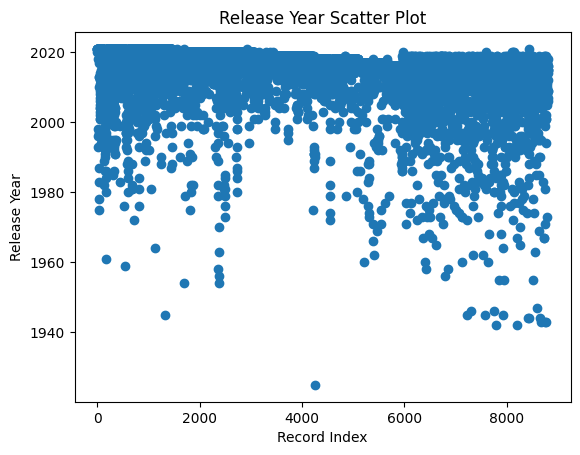

In [ ]:
plt.scatter(df.index, df['release_year'])
plt.title("Release Year Scatter Plot")
plt.xlabel("Record Index")
plt.ylabel("Release Year")
plt.show()

5. Pie Chart

Movies vs TV Shows Share

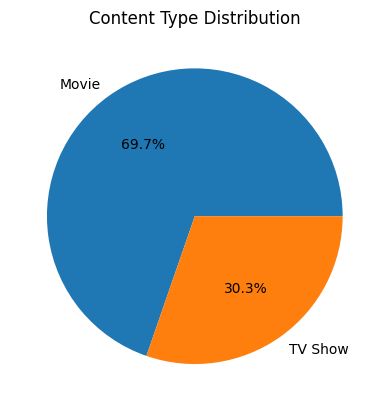

In [ ]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Content Type Distribution")
plt.ylabel('')
plt.show()

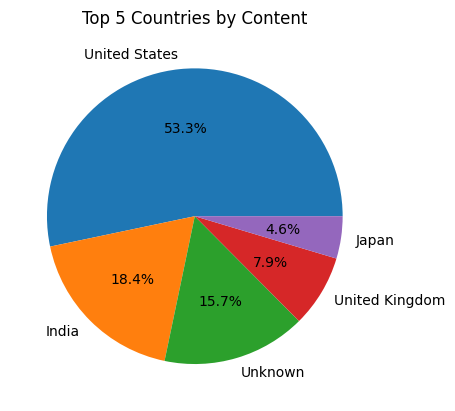

In [ ]:
df['country'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Top 5 Countries by Content")
plt.ylabel('')
plt.show()

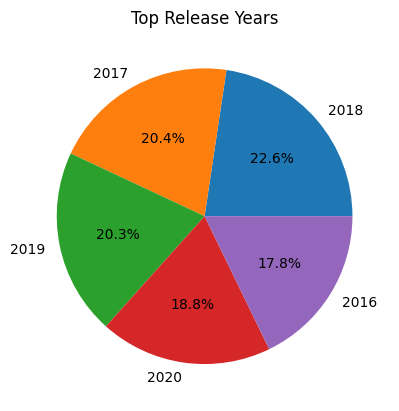

In [ ]:
df['release_year'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Top Release Years")
plt.ylabel('')
plt.show()

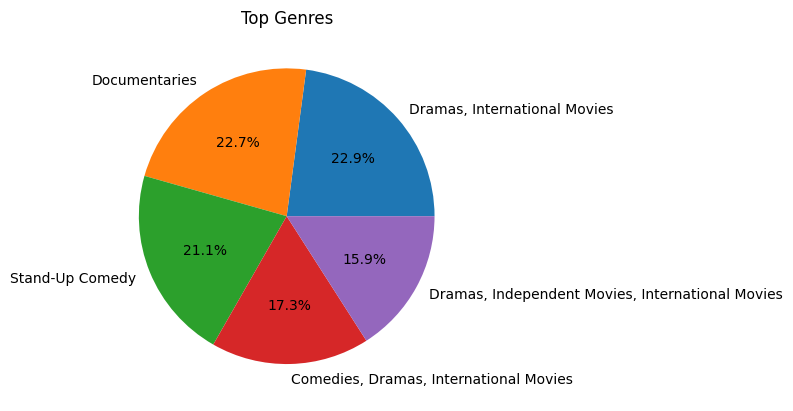

In [ ]:
df['listed_in'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Top Genres")
plt.ylabel('')
plt.show()

6. Heatmap

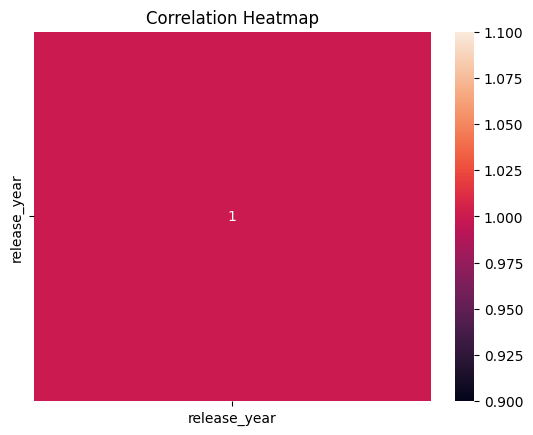

In [ ]:
import seaborn as sns

numeric_df = df[['release_year']]

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

Step 5 — Insights Report
Insight 1

Movies are significantly more numerous than TV Shows on Netflix (Bar Chart & Pie Chart).

Insight 2

The United States contributes the largest amount of Netflix content (Country Analysis).

Insight 3

Content production increased rapidly after 2015 (Line Chart).

Insight 4

TV-MA is among the most common content ratings on Netflix (Ratings Analysis).

Insight 5

Movies and shows released between 2015–2021 dominate the catalog (Histogram).